# CC 311 Econometrics — Unit 5 - Lecture 2.0
## AR, MA → ARMA → ACF/PACF → ARIMA → Forecasting

**Teaching goal:** move from the intuition of time-series memory to an actual forecasting workflow.

This notebook is designed to be run **side-by-side with the Lecture 2 PPT**. Students can change parameters and immediately see how the simulated series, ACF/PACF and forecasts respond.

### Roadmap
1. AR and MA intuition
2. ARMA(1,1)
3. ACF and PACF
4. AR vs MA identification
5. Non-stationarity and differencing
6. ARIMA(p,d,q)
7. Forecasting
8. Diagnostics
9. Optional real-data exercise

> **Note:** the simulated examples are deliberately simple. The purpose is to make the econometric ideas visible before moving to real data.


In [ ]:
#@title Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
np.random.seed(42)




## 1. AR(1): persistence from past values

The basic AR(1) model is

$$Y_t = c + \phi Y_{t-1} + \varepsilon_t$$

The key teaching question is:

> **What happens when we increase $\phi$?**

*   **Small $|\phi|$:** weak persistence.
*   **Larger positive $\phi$:** observations tend to remain elevated/depressed for longer.
*   **Negative $\phi$:** successive movements tend to alternate.
*   **For a stationary AR(1):** $|\phi| < 1$.


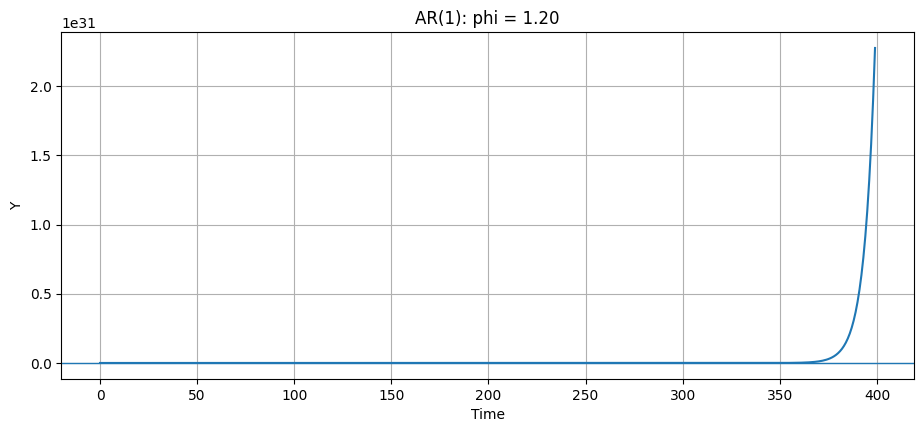

In [ ]:
#@title Interactive AR(1) simulator

phi = 1.2 #@param {type:"slider", min:-2, max:2, step:0.05}
sigma = 0.5 #@param {type:"slider", min:0.2, max:3.0, step:0.1}
n = 400 #@param {type:"slider", min:100, max:1000, step:50}

eps = np.random.normal(0, sigma, n)
y = np.zeros(n)
for t in range(1, n):
    y[t] = phi*y[t-1] + eps[t]

fig, ax = plt.subplots()
ax.plot(y)
ax.axhline(0, linewidth=1)
ax.set_title(f"AR(1): phi = {phi:.2f}")
ax.set_xlabel("Time")
ax.set_ylabel("Y")
plt.show()


### Try to answer:


1. What happens to persistence?
2. Why does a large positive \\(\phi\\) make shocks appear to “last”?
3. Why does a negative \\(\phi\\) produce alternating movements?
4. What happens as we approach the non-stationary boundary?


## 2. MA(1): memory of shocks

The MA(1) model is

$$Y_t = \mu + \varepsilon_t + \theta\varepsilon_{t-1}$$

Unlike AR, the model does **not** use the previous value of $Y$. It uses the current and previous **innovations/shocks**.

This gives a useful contrast:

> **AR remembers values; MA remembers shocks.**



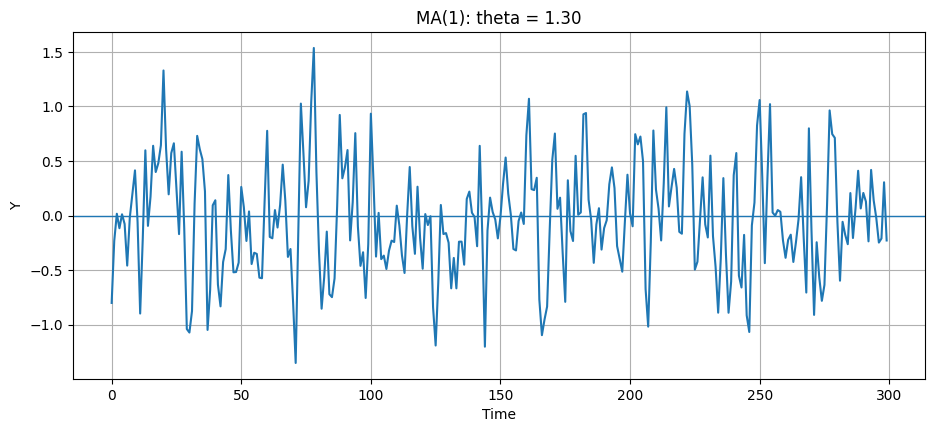

In [ ]:
#@title Interactive MA(1) simulator

theta = 1.3 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}
sigma = 0.3 #@param {type:"slider", min:0.2, max:3.0, step:0.1}
n = 300 #@param {type:"slider", min:100, max:1000, step:50}

eps = np.random.normal(0, sigma, n+1)
y = eps[1:] + theta*eps[:-1]

fig, ax = plt.subplots()
ax.plot(y)
ax.axhline(0, linewidth=1)
ax.set_title(f"MA(1): theta = {theta:.2f}")
ax.set_xlabel("Time")
ax.set_ylabel("Y")
plt.show()


**Question:**

What is happening to stationarity while we are changing $\theta$.


## 3. ARMA(1,1): both kinds of memory

Now combine the two:

$$Y_t = c + \phi Y_{t-1} + \varepsilon_t + \theta\varepsilon_{t-1}$$

There are now two channels:

*   **AR component ($\phi$):** persistence from past values.
*   **MA component ($\theta$):** effect of recent shocks.


This is the first model where students should see why AR and MA can complement each other.


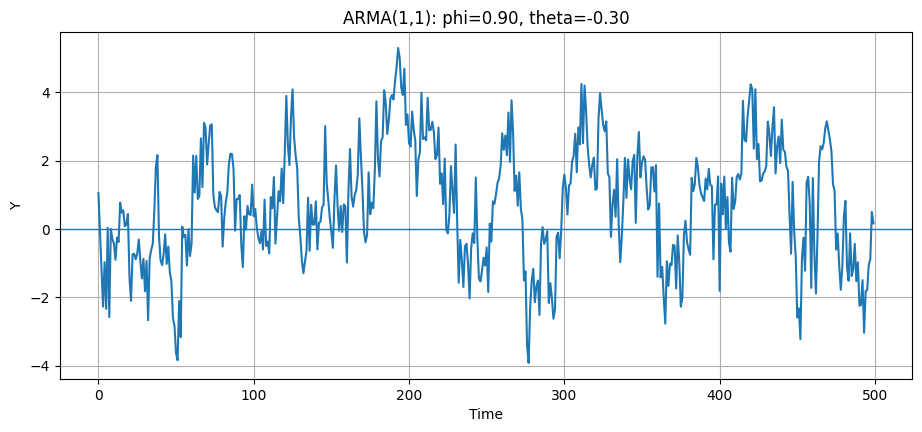

In [ ]:
#@title Interactive ARMA(1,1)

phi = 0.9 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}
theta = -0.3 #@param {type:"slider", min:-1.5, max:1.5, step:0.1}
n = 500 #@param {type:"slider", min:100, max:1000, step:50}

ar = np.array([1, -phi])
ma = np.array([1, theta])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=n)

fig, ax = plt.subplots()
ax.plot(y)
ax.axhline(0, linewidth=1)
ax.set_title(f"ARMA(1,1): phi={phi:.2f}, theta={theta:.2f}")
ax.set_xlabel("Time")
ax.set_ylabel("Y")
plt.show()


## 4. ACF: how much does the series remember?

The autocorrelation at lag $k$ measures the correlation between

$$Y_t \quad \text{and} \quad Y_{t-k}$$

So the ACF answers:

> **How strongly is today's observation related to the observation $k$ periods ago?**

The ACF is therefore a visual summary of time-series dependence.



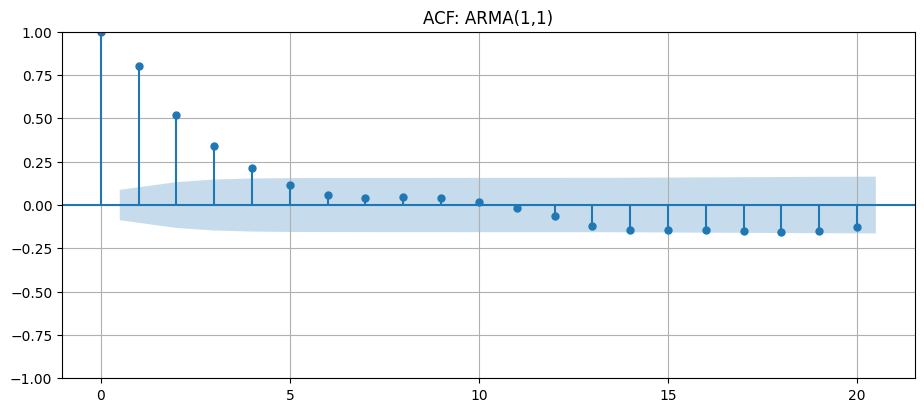

In [ ]:
#@title ACF explorer

series_choice = "ARMA(1,1)" #@param ["AR(1)", "MA(1)", "ARMA(1,1)"]

np.random.seed(7)
n = 500

if series_choice == "AR(1)":
    phi = 0.75
    eps = np.random.normal(size=n)
    y = np.zeros(n)
    for t in range(1,n):
        y[t] = phi*y[t-1] + eps[t]
elif series_choice == "MA(1)":
    theta = 0.75
    eps = np.random.normal(size=n+1)
    y = eps[1:] + theta*eps[:-1]
else:
    process = ArmaProcess([1,-0.7],[1,0.5])
    y = process.generate_sample(nsample=n)

fig, ax = plt.subplots()
plot_acf(y, lags=20, ax=ax, alpha=0.05)
ax.set_title(f"ACF: {series_choice}")
plt.show()


## 5. PACF: the direct relationship at a lag

PACF asks whether lag \(k\) still has an association with the current value **after accounting for the intermediate lags**.

A useful classroom interpretation:

> ACF shows overall dependence across lags; PACF helps isolate the incremental/direct contribution of a particular lag.


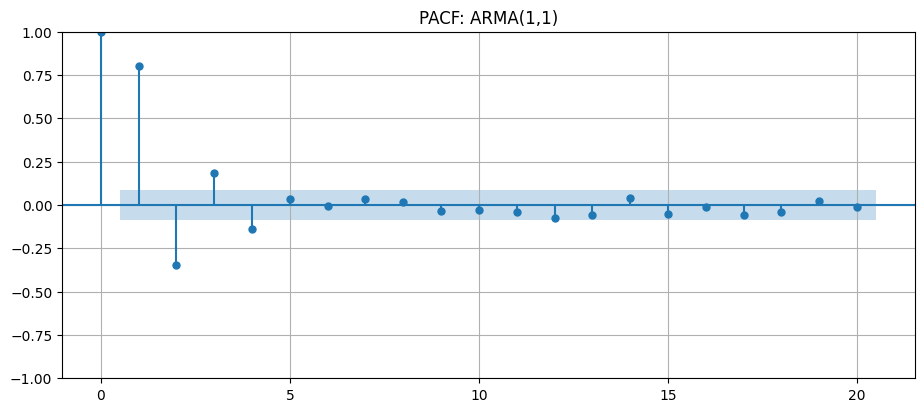

In [ ]:
#@title PACF explorer

fig, ax = plt.subplots()
plot_pacf(y, lags=20, ax=ax, method="ywm", alpha=0.05)
ax.set_title(f"PACF: {series_choice}")
plt.show()


## 6. The identification heuristic

For a stationary series, a common starting rule is:

| Candidate | ACF | PACF |
|---|---|---|
| **AR(p)** | gradual decay | cuts off around p |
| **MA(q)** | cuts off around q | gradual decay |
| **ARMA(p,q)** | gradual decay | gradual decay |

These are **identification clues**, not mechanical laws. We still estimate candidate models and diagnose them.


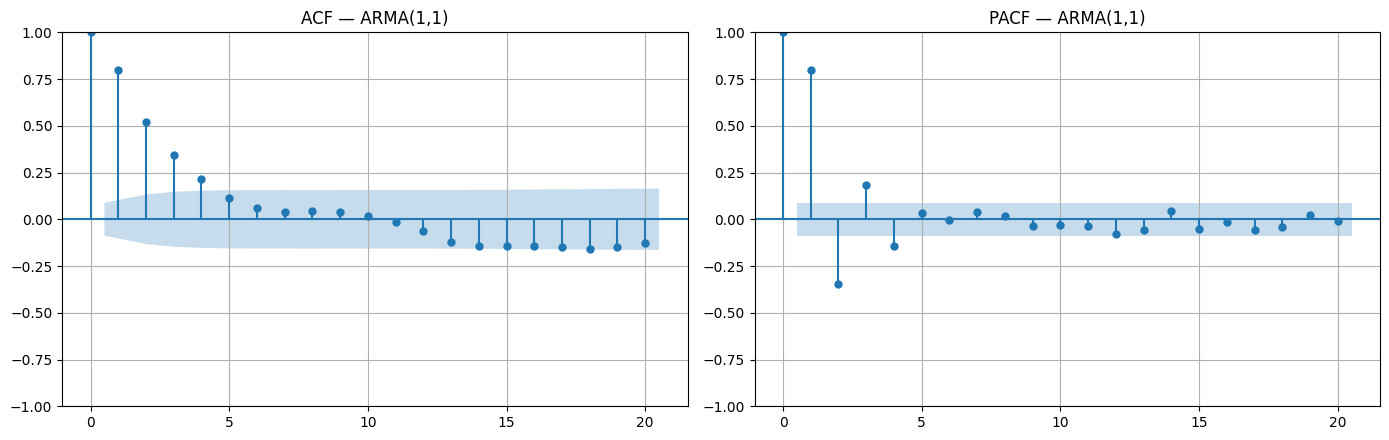

In [ ]:
#@title Side-by-side ACF and PACF

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(y, lags=20, ax=axes[0], alpha=0.05)
axes[0].set_title(f"ACF — {series_choice}")

plot_pacf(y, lags=20, ax=axes[1], method="ywm", alpha=0.05)
axes[1].set_title(f"PACF — {series_choice}")

plt.tight_layout()
plt.show()


# 7. Non-stationarity and differencing

Suppose the series has a trend or changing level.
The first difference is

$$\Delta Y_t = Y_t - Y_{t-1}$$

The intuition is important:

> We are not trying to make the data “better” by removing information. We are changing the representation so that the **stochastic dynamics can be modelled as approximately stable over time**.

This is the bridge from ARMA to **ARIMA**.


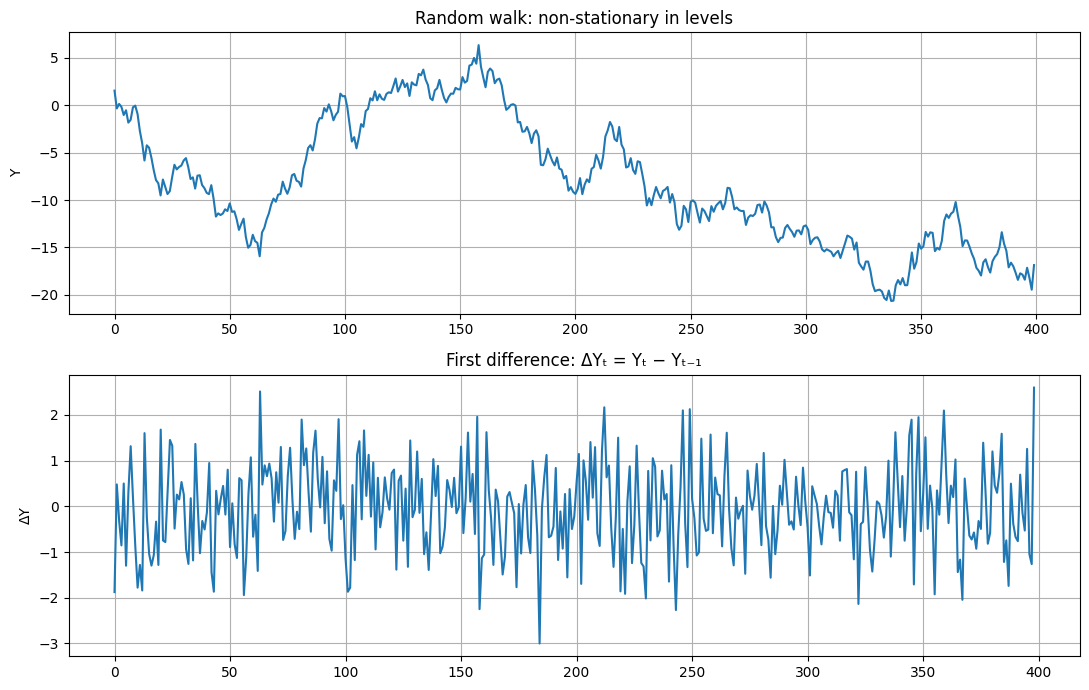

In [ ]:
#@title Random walk → first difference

n = 400
eps = np.random.normal(size=n)

random_walk = np.cumsum(eps)
difference = np.diff(random_walk)

fig, axes = plt.subplots(2, 1, figsize=(11, 7))

axes[0].plot(random_walk)
axes[0].set_title("Random walk: non-stationary in levels")
axes[0].set_ylabel("Y")

axes[1].plot(difference)
axes[1].set_title("First difference: ΔYₜ = Yₜ − Yₜ₋₁")
axes[1].set_ylabel("ΔY")

plt.tight_layout()
plt.show()


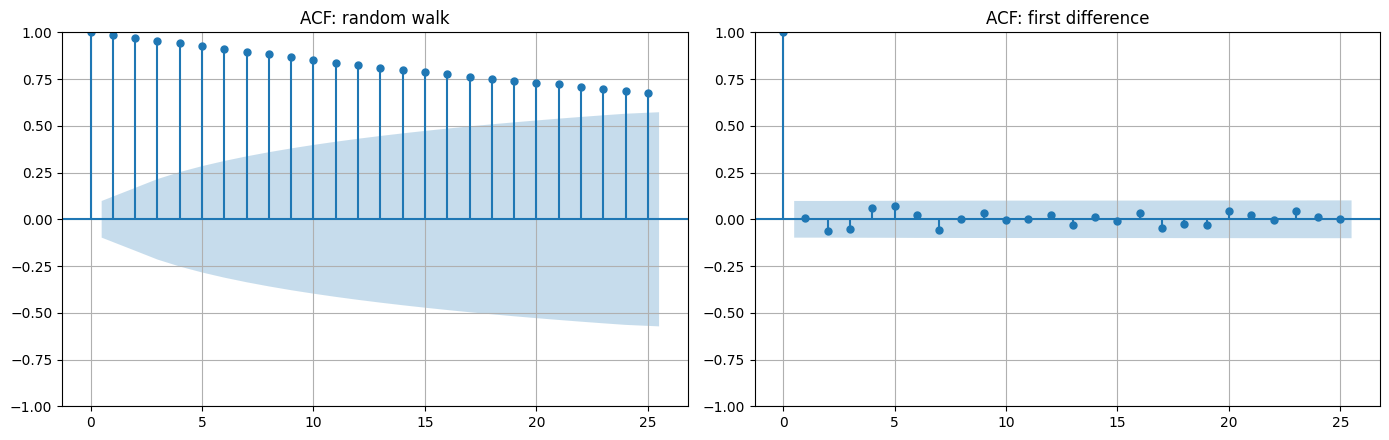

In [ ]:
#@title Compare ACF before and after differencing

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(random_walk, lags=25, ax=axes[0], alpha=0.05)
axes[0].set_title("ACF: random walk")

plot_acf(difference, lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title("ACF: first difference")

plt.tight_layout()
plt.show()


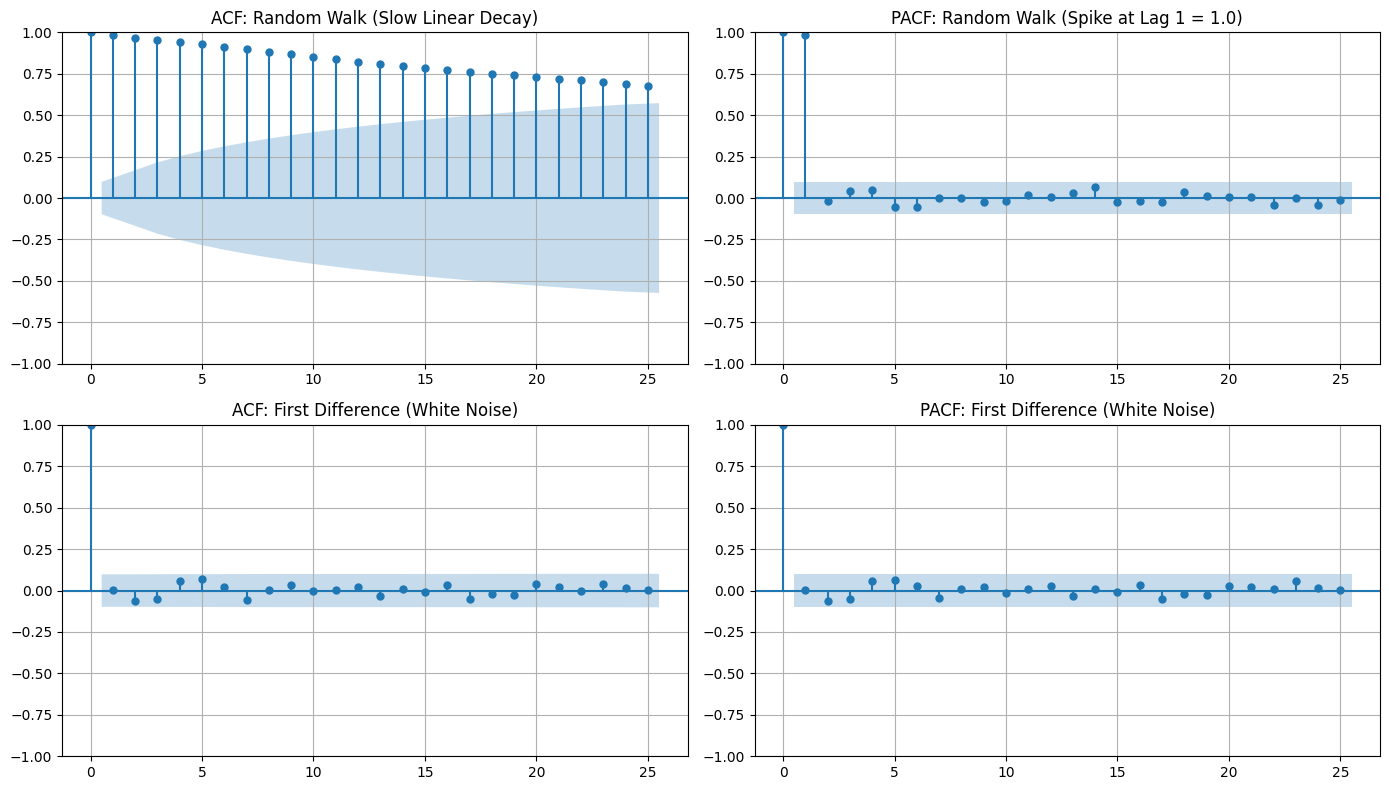

In [ ]:
#@title Complete Diagnostic Grid: Before & After Differencing


# Creating a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# --- BEFORE DIFFERENCING (Random Walk) ---
plot_acf(random_walk, lags=25, ax=axes[0, 0], alpha=0.05)
axes[0, 0].set_title("ACF: Random Walk (Slow Linear Decay)")

plot_pacf(random_walk, lags=25, ax=axes[0, 1], alpha=0.05, method='ywm')
axes[0, 1].set_title("PACF: Random Walk (Spike at Lag 1 = 1.0)")

# --- AFTER DIFFERENCING (First Difference) ---
plot_acf(difference, lags=25, ax=axes[1, 0], alpha=0.05)
axes[1, 0].set_title("ACF: First Difference (White Noise)")

plot_pacf(difference, lags=25, ax=axes[1, 1], alpha=0.05, method='ywm')
axes[1, 1].set_title("PACF: First Difference (White Noise)")

plt.tight_layout()
plt.show()


## 8. ARIMA(p,d,q)

\[
ARIMA(p,d,q)
\]

- **p** = number/order of AR terms
- **d** = number of differences
- **q** = number/order of MA terms

For example:

\[
ARIMA(1,1,1)
\]

means:

1. Difference the original series once.
2. Model the differenced series with AR and MA dynamics.
3. Use that model to forecast the original series.


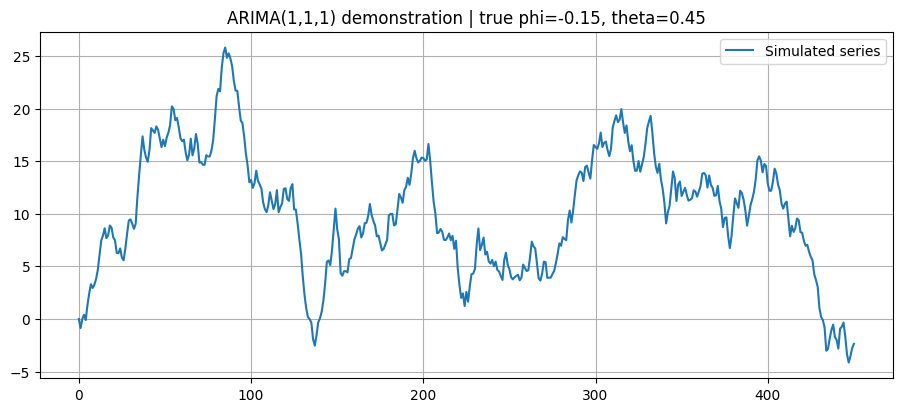

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  451
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -630.351
Date:                Mon, 05 Oct 2026   AIC                           1266.702
Time:                        08:21:50   BIC                           1279.030
Sample:                             0   HQIC                          1271.561
                                - 451                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0341      0.146      0.233      0.816      -0.252       0.321
ma.L1          0.2682      0.145      1.854      0.064      -0.015       0.552
sigma2         0.9641      0.071     13.524      0.0

In [ ]:
#@title Interactive ARIMA simulation + estimation

phi = -0.15 #@param {type:"slider", min:-0.85, max:0.85, step:0.05}
theta = 0.45 #@param {type:"slider", min:-1.2, max:1.2, step:0.05}
n = 450 #@param {type:"slider", min:200, max:800, step:50}

# Simulate an I(1) process whose first difference follows ARMA(1,1)
eps = np.random.normal(size=n+1)
dy = np.zeros(n+1)

for t in range(1, n+1):
    dy[t] = phi*dy[t-1] + eps[t] + theta*eps[t-1]

y = np.cumsum(dy)

model = ARIMA(y, order=(1,1,1)).fit()

fig, ax = plt.subplots()
ax.plot(y, label="Simulated series")
ax.set_title(f"ARIMA(1,1,1) demonstration | true phi={phi:.2f}, theta={theta:.2f}")
ax.legend()
plt.show()

print(model.summary())


# 9. Forecasting

A forecast is a conditional prediction:
$$ \hat Y_{t+1|t}=E(Y_{t+1}\mid \mathcal I_t) $$
In plain English:
> **Given everything we know up to time t, what is our best prediction of the next observation?**

We will now deliberately hold out the final observations so that forecasting becomes a genuine out-of-sample exercise.


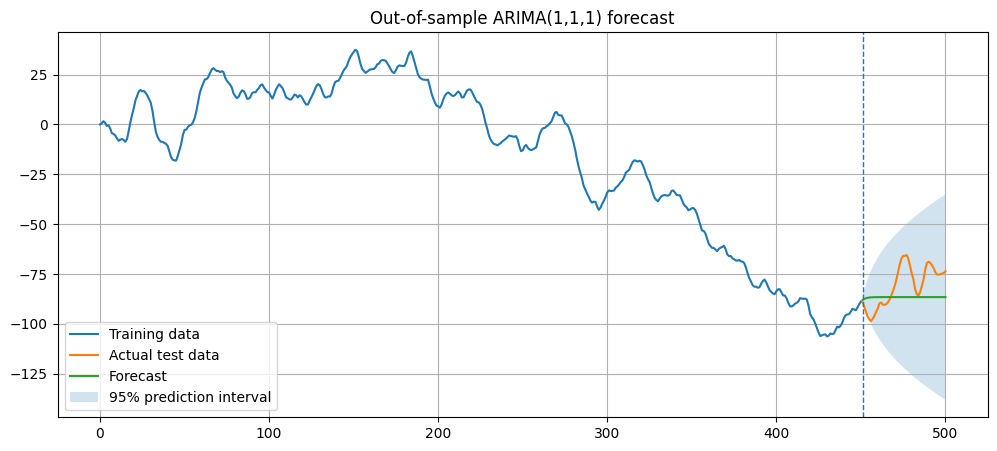

In [ ]:
#@title Train/test forecasting exercise

# Use a fresh simulated ARIMA(1,1,1)-type series
np.random.seed(123)
n = 500
eps = np.random.normal(size=n+1)
dy = np.zeros(n+1)

phi_true = 0.65
theta_true = 0.40

for t in range(1,n+1):
    dy[t] = phi_true*dy[t-1] + eps[t] + theta_true*eps[t-1]

y = np.cumsum(dy)

test_size = 50
train = y[:-test_size]
test = y[-test_size:]

model = ARIMA(train, order=(1,1,1)).fit()
forecast_res = model.get_forecast(steps=test_size)
forecast = forecast_res.predicted_mean
ci = forecast_res.conf_int()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(np.arange(len(train)), train, label="Training data")
ax.plot(np.arange(len(train), len(y)), test, label="Actual test data")
ax.plot(np.arange(len(train), len(y)), forecast, label="Forecast")
ax.fill_between(np.arange(len(train), len(y)), ci[:,0], ci[:,1], alpha=0.20, label="95% prediction interval")
ax.axvline(len(train), linestyle="--", linewidth=1)
ax.set_title("Out-of-sample ARIMA(1,1,1) forecast")
ax.legend()
plt.show()


In [ ]:
#@title Forecast accuracy

from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print(f"MAE  = {mae:.3f}")
print(f"RMSE = {rmse:.3f}")


MAE  = 9.731
RMSE = 11.433


### Questions:

Ask yourself:

- Why do we keep the last 50 observations out of estimation?
- Why is an in-sample fitted line not enough?
- What does the prediction interval tell us?
- Why does uncertainty usually increase as the forecast horizon becomes longer?
- Does this forecast look good to you? If not what went wrong? What did we not consider?
The key distinction is:

**Fitted values ≠ forecasts.**


# 10. Model diagnostics

A model can fit the historical data reasonably well and still be a poor time-series model.

A basic requirement is that the residuals should behave approximately like **white noise**:

- little systematic autocorrelation;
- no obvious predictable pattern left in the residuals.

We can inspect the residual ACF and use a Ljung–Box test as a formal diagnostic.


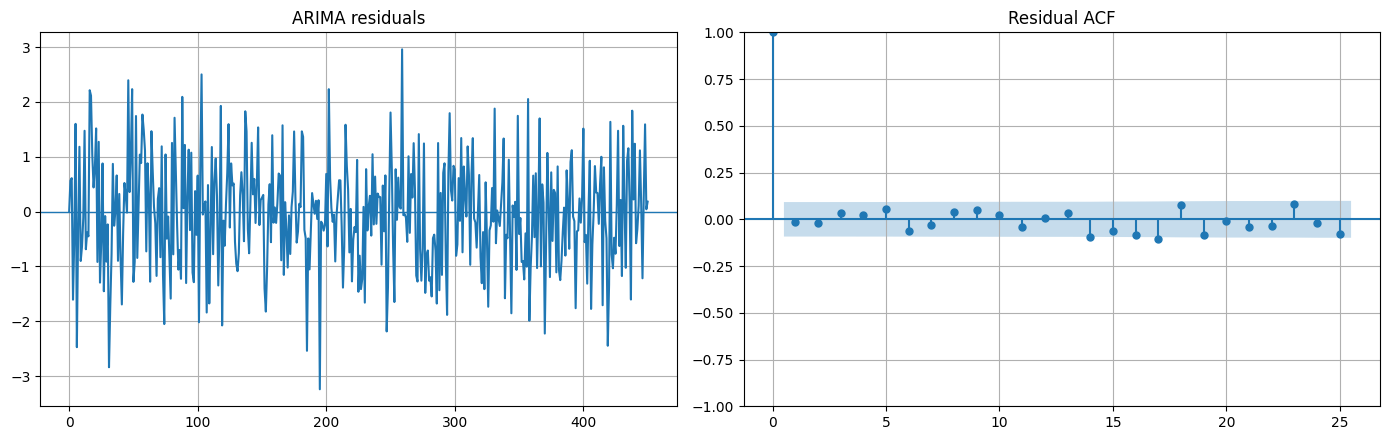

      lb_stat  lb_pvalue
10   6.956435   0.729551
20  28.440641   0.099372


In [ ]:
#@title Residual diagnostics

resid = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14,4.5))

axes[0].plot(resid)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("ARIMA residuals")

plot_acf(resid, lags=25, ax=axes[1], alpha=0.05)
axes[1].set_title("Residual ACF")

plt.tight_layout()
plt.show()

lb = acorr_ljungbox(resid, lags=[10, 20], return_df=True)
print(lb)
